In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt

df = pd.read_csv('Homework_3_Dataset_Smart_home 1.csv')
df['Next Time'] = df['Time'].shift(-1)
df.loc[df.index[-1], 'Next Time'] = df.loc[df.index[0], 'Time']
df['Next Time'] = df['Next Time'].astype(int)
df['Next Electricity Price'] = df['Electricity Price'].shift(-1)
df.loc[df.index[-1], 'Next Electricity Price'] = df.loc[df.index[0], 'Electricity Price']
df['Next User Activity'] = df['User Activity'].shift(-1)
df.loc[df.index[-1], 'Next User Activity'] = df.loc[df.index[0], 'User Activity']
df['Next User Activity'] = df['Next User Activity'].astype(int)


In [34]:
time = 24
user_activity = 2
appliance_state = 2
action = 2

epsilon = 1.0 # exploration rate for ɛ-Greedy
epsilon_min = 0.01
decay = 0.9995
n_epoch = 10000
penalty = 1.0 #user comfort penalty

q_table = np.zeros((time, user_activity, appliance_state, action))
total_reward = []

Training the Q-Learning Agent

In [35]:
for epoch in range(n_epoch):
    current_appliance_state = random.choice([0, 1])
    epoch_reward = 0
    for index, row in df.iterrows():
        current_time = int(row['Time'])
        current_user_activity = int(row['User Activity'])
        state = (current_time, current_user_activity, current_appliance_state)
        state_idx = state
        if random.uniform(0, 1) < epsilon:
            action = random.choice([0, 1])
        else:
            action = np.argmax(q_table[state_idx])
        next_time = int(row['Next Time'])
        next_user_activity = int(row['Next User Activity'])
        next_electricity_price = row['Next Electricity Price']
        next_appliance_state = action
        next_state = (next_time, next_user_activity, next_appliance_state)
        next_state_idx = next_state
        
        reward = 0
        if next_appliance_state == 1:
            reward = -next_electricity_price
        elif next_appliance_state == 0 and next_user_activity == 1:
            reward = -penalty
        epoch_reward += reward
        old_value = q_table[state_idx + (action,)]
        next_max_q = np.max(q_table[next_state_idx])
        target = reward + 0.95 * next_max_q # 0.95 as gamma or discount factor
        new_value = old_value + 0.1 * (target - old_value) # 0.1 as alpha or learning rate
        q_table[state_idx + (action,)] = new_value
        current_appliance_state = next_appliance_state
    if epsilon > epsilon_min:
        epsilon *= decay
    total_reward.append(epoch_reward)
    if (epoch + 1) % 1000 == 0:
        print(f"Epoch {epoch + 1}/{n_epoch}, Reward: {epoch_reward:.2f}, Eps: {epsilon:.3f}")

Epoch 1000/10000, Reward: -209.68, Eps: 0.606
Epoch 2000/10000, Reward: -181.18, Eps: 0.368
Epoch 3000/10000, Reward: -186.77, Eps: 0.223
Epoch 4000/10000, Reward: -169.70, Eps: 0.135
Epoch 5000/10000, Reward: -167.03, Eps: 0.082
Epoch 6000/10000, Reward: -162.62, Eps: 0.050
Epoch 7000/10000, Reward: -160.81, Eps: 0.030
Epoch 8000/10000, Reward: -159.15, Eps: 0.018
Epoch 9000/10000, Reward: -158.29, Eps: 0.011
Epoch 10000/10000, Reward: -159.02, Eps: 0.010


Test the learned policy, check the model's result at 12 (Noon)

In [36]:
for user_act in [0, 1]:
    for app_state in [0, 1]:
        state_idx = (12, user_act, app_state)
        action = np.argmax(q_table[state_idx])
        print(f" State (T=12, User={user_act}, Appliance={app_state}): Recommended action = {action} (Q-vals: {q_table[state_idx].round(3)})")

total_cost = 0
comfort_violations = 0
agent_schedule = []
current_appliance_state = 0
cumulative_reward = 0

 State (T=12, User=0, Appliance=0): Recommended action = 1 (Q-vals: [-4.532 -4.512])
 State (T=12, User=0, Appliance=1): Recommended action = 1 (Q-vals: [-4.583 -4.508])
 State (T=12, User=1, Appliance=0): Recommended action = 0 (Q-vals: [-4.221 -4.489])
 State (T=12, User=1, Appliance=1): Recommended action = 1 (Q-vals: [-4.661 -4.485])


In [37]:
for index, row in df.iterrows():
    current_time = int(row['Time'])
    current_user_activity = int(row['User Activity'])
    current_price = row['Electricity Price']
    next_user_activity = int(row['Next User Activity'])
    next_price = row['Next Electricity Price']
    state_idx = (current_time, current_user_activity, current_appliance_state)
    action = np.argmax(q_table[state_idx])
    agent_schedule.append(action)
    next_appliance_state_actual = action
    if next_appliance_state_actual == 1:
        cost_incurred = next_price
        total_cost += cost_incurred
        reward = -cost_incurred
    else:
        reward = 0
        if next_user_activity == 1:
            comfort_violations += 1
            reward = -0.5
    
    cumulative_reward += reward
    current_appliance_state = next_appliance_state_actual

Evaluation of the model during training

Total Electricity Cost: $150.49
Number of Comfort Violations (Appliance OFF when User Active): 7
Total Reward (during evaluation): -153.99


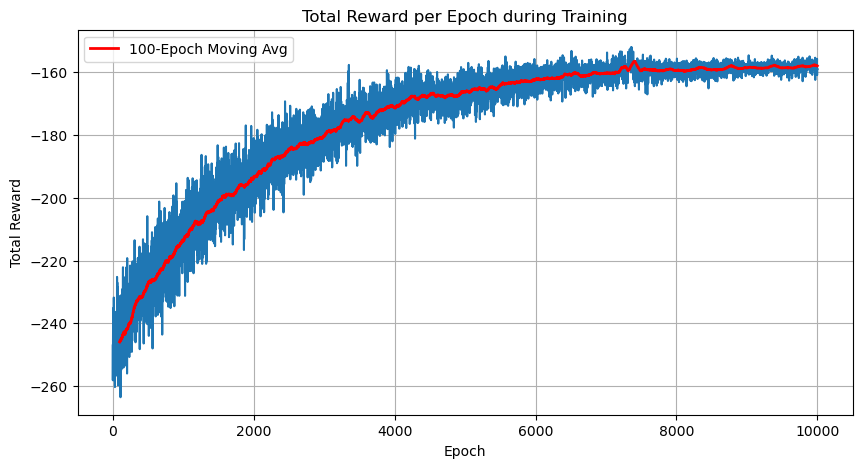

In [38]:
print(f"Total Electricity Cost: ${total_cost:.2f}")
print(f"Number of Comfort Violations (Appliance OFF when User Active): {comfort_violations}")
print(f"Total Reward (during evaluation): {cumulative_reward:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(total_reward)
plt.title('Total Reward per Epoch during Training')
plt.xlabel('Epoch')
plt.ylabel('Total Reward')
plt.grid(True)
if len(total_reward) >= 50:
    moving_avg = pd.Series(total_reward).rolling(100).mean()
    plt.plot(moving_avg, label='100-Epoch Moving Avg', color='red', linewidth=2)
    plt.legend()
plt.show()


--- Baselines for Comparison ---
Baseline (Always ON): Cost=$165.83, Violations=0, Reward=-165.83
Baseline (Always OFF): Cost=$0.00, Violations=328, Reward=-328.00
Baseline (ON if Active Next - 'Before'): Cost=$76.74, Violations=0, Reward=-76.74


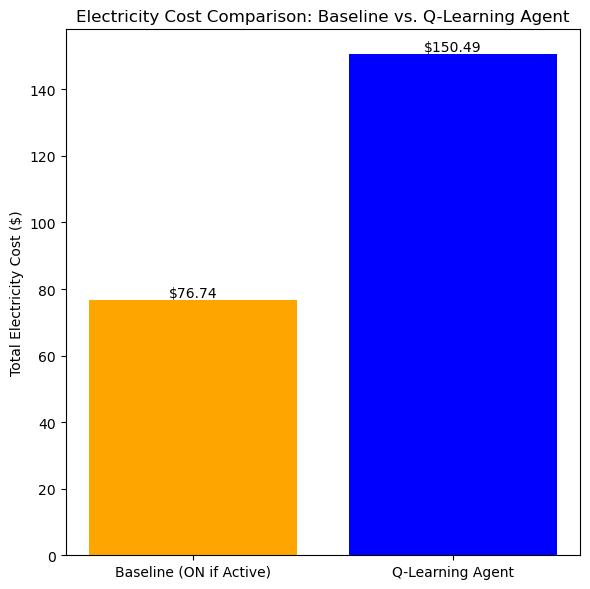

In [40]:
print("\n--- Baselines for Comparison ---")
# Always ON
cost_always_on = df['Next Electricity Price'].sum()
violations_always_on = 0
reward_always_on = -cost_always_on
print(f"Baseline (Always ON): Cost=${cost_always_on:.2f}, Violations={violations_always_on}, Reward={reward_always_on:.2f}")

# Always OFF
cost_always_off = 0
violations_always_off = df[df['Next User Activity'] == 1].shape[0]
reward_always_off = - (violations_always_off * penalty)
print(f"Baseline (Always OFF): Cost=${cost_always_off:.2f}, Violations={violations_always_off}, Reward={reward_always_off:.2f}")

# ON only when User is Active *in the next step* ("Before" scenario for cost optimization)
cost_baseline_active = df.loc[df['Next User Activity'] == 1, 'Next Electricity Price'].sum()
violations_baseline_active = 0
reward_baseline_active = - cost_baseline_active
print(f"Baseline (ON if Active Next - 'Before'): Cost=${cost_baseline_active:.2f}, Violations={violations_baseline_active}, Reward={reward_baseline_active:.2f}")

scenarios = ['Baseline (ON if Active)', 'Q-Learning Agent']
costs = [cost_baseline_active, total_cost]
plt.figure(figsize=(6, 6))
bars = plt.bar(scenarios, costs, color=['orange', 'blue'])
plt.ylabel('Total Electricity Cost ($)')
plt.title('Electricity Cost Comparison: Baseline vs. Q-Learning Agent')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'${yval:.2f}', va='bottom', ha='center')
plt.tight_layout()
plt.show()